In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

# read csv file
df = pd.read_csv('databases.csv')

# convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'])

# convert european decimal format (comma) to standard format (dot)
def convert_decimal(x):
    if pd.isna(x):
        return np.nan
    if isinstance(x, str):
        return float(x.replace(',', '.'))
    return float(x)

df['vectors_chao_score'] = df['vectors_chao_score'].apply(convert_decimal)
df['congestion_score'] = df['congestion_score'].apply(convert_decimal)

# sort by timestamp
df = df.sort_values('timestamp')

# extract date for grouping
df['date'] = df['timestamp'].dt.date

print(f"total rows: {len(df)}")
print(f"time range: {df['timestamp'].min()} to {df['timestamp'].max()}")
print(f"unique dates: {df['date'].nunique()}")
print(f"dates: {sorted(df['date'].unique())}")
df.head()

total rows: 1376
time range: 2025-11-26 16:17:47 to 2025-12-26 11:33:54
unique dates: 10
dates: [datetime.date(2025, 11, 26), datetime.date(2025, 11, 27), datetime.date(2025, 12, 1), datetime.date(2025, 12, 2), datetime.date(2025, 12, 6), datetime.date(2025, 12, 9), datetime.date(2025, 12, 10), datetime.date(2025, 12, 12), datetime.date(2025, 12, 24), datetime.date(2025, 12, 26)]


,camera_id,timestamp,car_count,truck_count,bus_count,motorcycle_count,road_area_pixels,vectors_chao_score,congestion_score,Unnamed: 9,date
17,587ee2aeb807da0011e33d52,2025-11-26 16:17:47,4,0,0,15,39902,0.449827,0.360773,NaN,2025-11-26
18,587ee2aeb807da0011e33d52,2025-11-26 16:18:08,5,0,0,8,41638,0.371382,0.301712,NaN,2025-11-26
19,587ee2aeb807da0011e33d52,2025-11-26 16:19:52,1,0,0,10,44149,0.233712,0.216285,NaN,2025-11-26
20,587ee2aeb807da0011e33d52,2025-11-26 16:20:14,5,0,0,15,22688,0.851152,0.660000,NaN,2025-11-26
21,587ee2aeb807da0011e33d52,2025-11-26 16:20:36,7,0,0,8,30051,0.538852,0.695916,1.0,2025-11-26


In [ ]:
# get unique dates
unique_dates = sorted(df['date'].unique())

# plot for each date
for date in unique_dates:
    # filter data for this date
    df_day = df[df['date'] == date].copy()
    
    if len(df_day) == 0:
        continue
    
    # create figure with 3 subplots
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    fig.suptitle(f'traffic statistics - {date}', fontsize=16, fontweight='bold')
    
    # chart 1: vehicle counts by type
    axes[0].plot(df_day['timestamp'], df_day['car_count'], label='car', marker='o', markersize=3, linewidth=1.5)
    axes[0].plot(df_day['timestamp'], df_day['truck_count'], label='truck', marker='s', markersize=3, linewidth=1.5)
    axes[0].plot(df_day['timestamp'], df_day['bus_count'], label='bus', marker='^', markersize=3, linewidth=1.5)
    axes[0].plot(df_day['timestamp'], df_day['motorcycle_count'], label='motorcycle', marker='d', markersize=3, linewidth=1.5)
    axes[0].set_xlabel('time (hour)')
    axes[0].set_ylabel('vehicle count')
    axes[0].set_title('vehicle counts by type over time')
    axes[0].legend(loc='upper right')
    axes[0].grid(True, alpha=0.3)
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[0].xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # chart 2: road area detected
    axes[1].plot(df_day['timestamp'], df_day['road_area_pixels'], color='green', linewidth=2)
    axes[1].set_xlabel('time (hour)')
    axes[1].set_ylabel('road area (pixels)')
    axes[1].set_title('detected road area over time')
    axes[1].grid(True, alpha=0.3)
    axes[1].fill_between(df_day['timestamp'], df_day['road_area_pixels'], alpha=0.3, color='green')
    axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[1].xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # chart 3: vectors chaos score
    axes[2].plot(df_day['timestamp'], df_day['vectors_chao_score'], color='red', linewidth=2)
    axes[2].set_xlabel('time (hour)')
    axes[2].set_ylabel('vectors chaos score')
    axes[2].set_title('vectors chaos score over time')
    axes[2].grid(True, alpha=0.3)
    axes[2].fill_between(df_day['timestamp'], df_day['vectors_chao_score'], alpha=0.3, color='red')
    axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    axes[2].xaxis.set_major_locator(mdates.HourLocator(interval=1))
    plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
    
    # adjust layout
    plt.tight_layout()
    plt.show()
    
    print(f"\ndate: {date} - total records: {len(df_day)}")
    print("="*60)

In [ ]:
# statistics summary by date
for date in unique_dates:
    df_day = df[df['date'] == date]
    
    print("\n" + "=" * 60)
    print(f"statistics for {date}")
    print("=" * 60)
    print(f"total records: {len(df_day)}")
    print(f"time range: {df_day['timestamp'].min()} to {df_day['timestamp'].max()}")
    
    print("\nvehicle count statistics:")
    print(df_day[['car_count', 'truck_count', 'bus_count', 'motorcycle_count']].describe())
    
    print("\nroad area and chaos score statistics:")
    print(df_day[['road_area_pixels', 'vectors_chao_score', 'congestion_score']].describe())

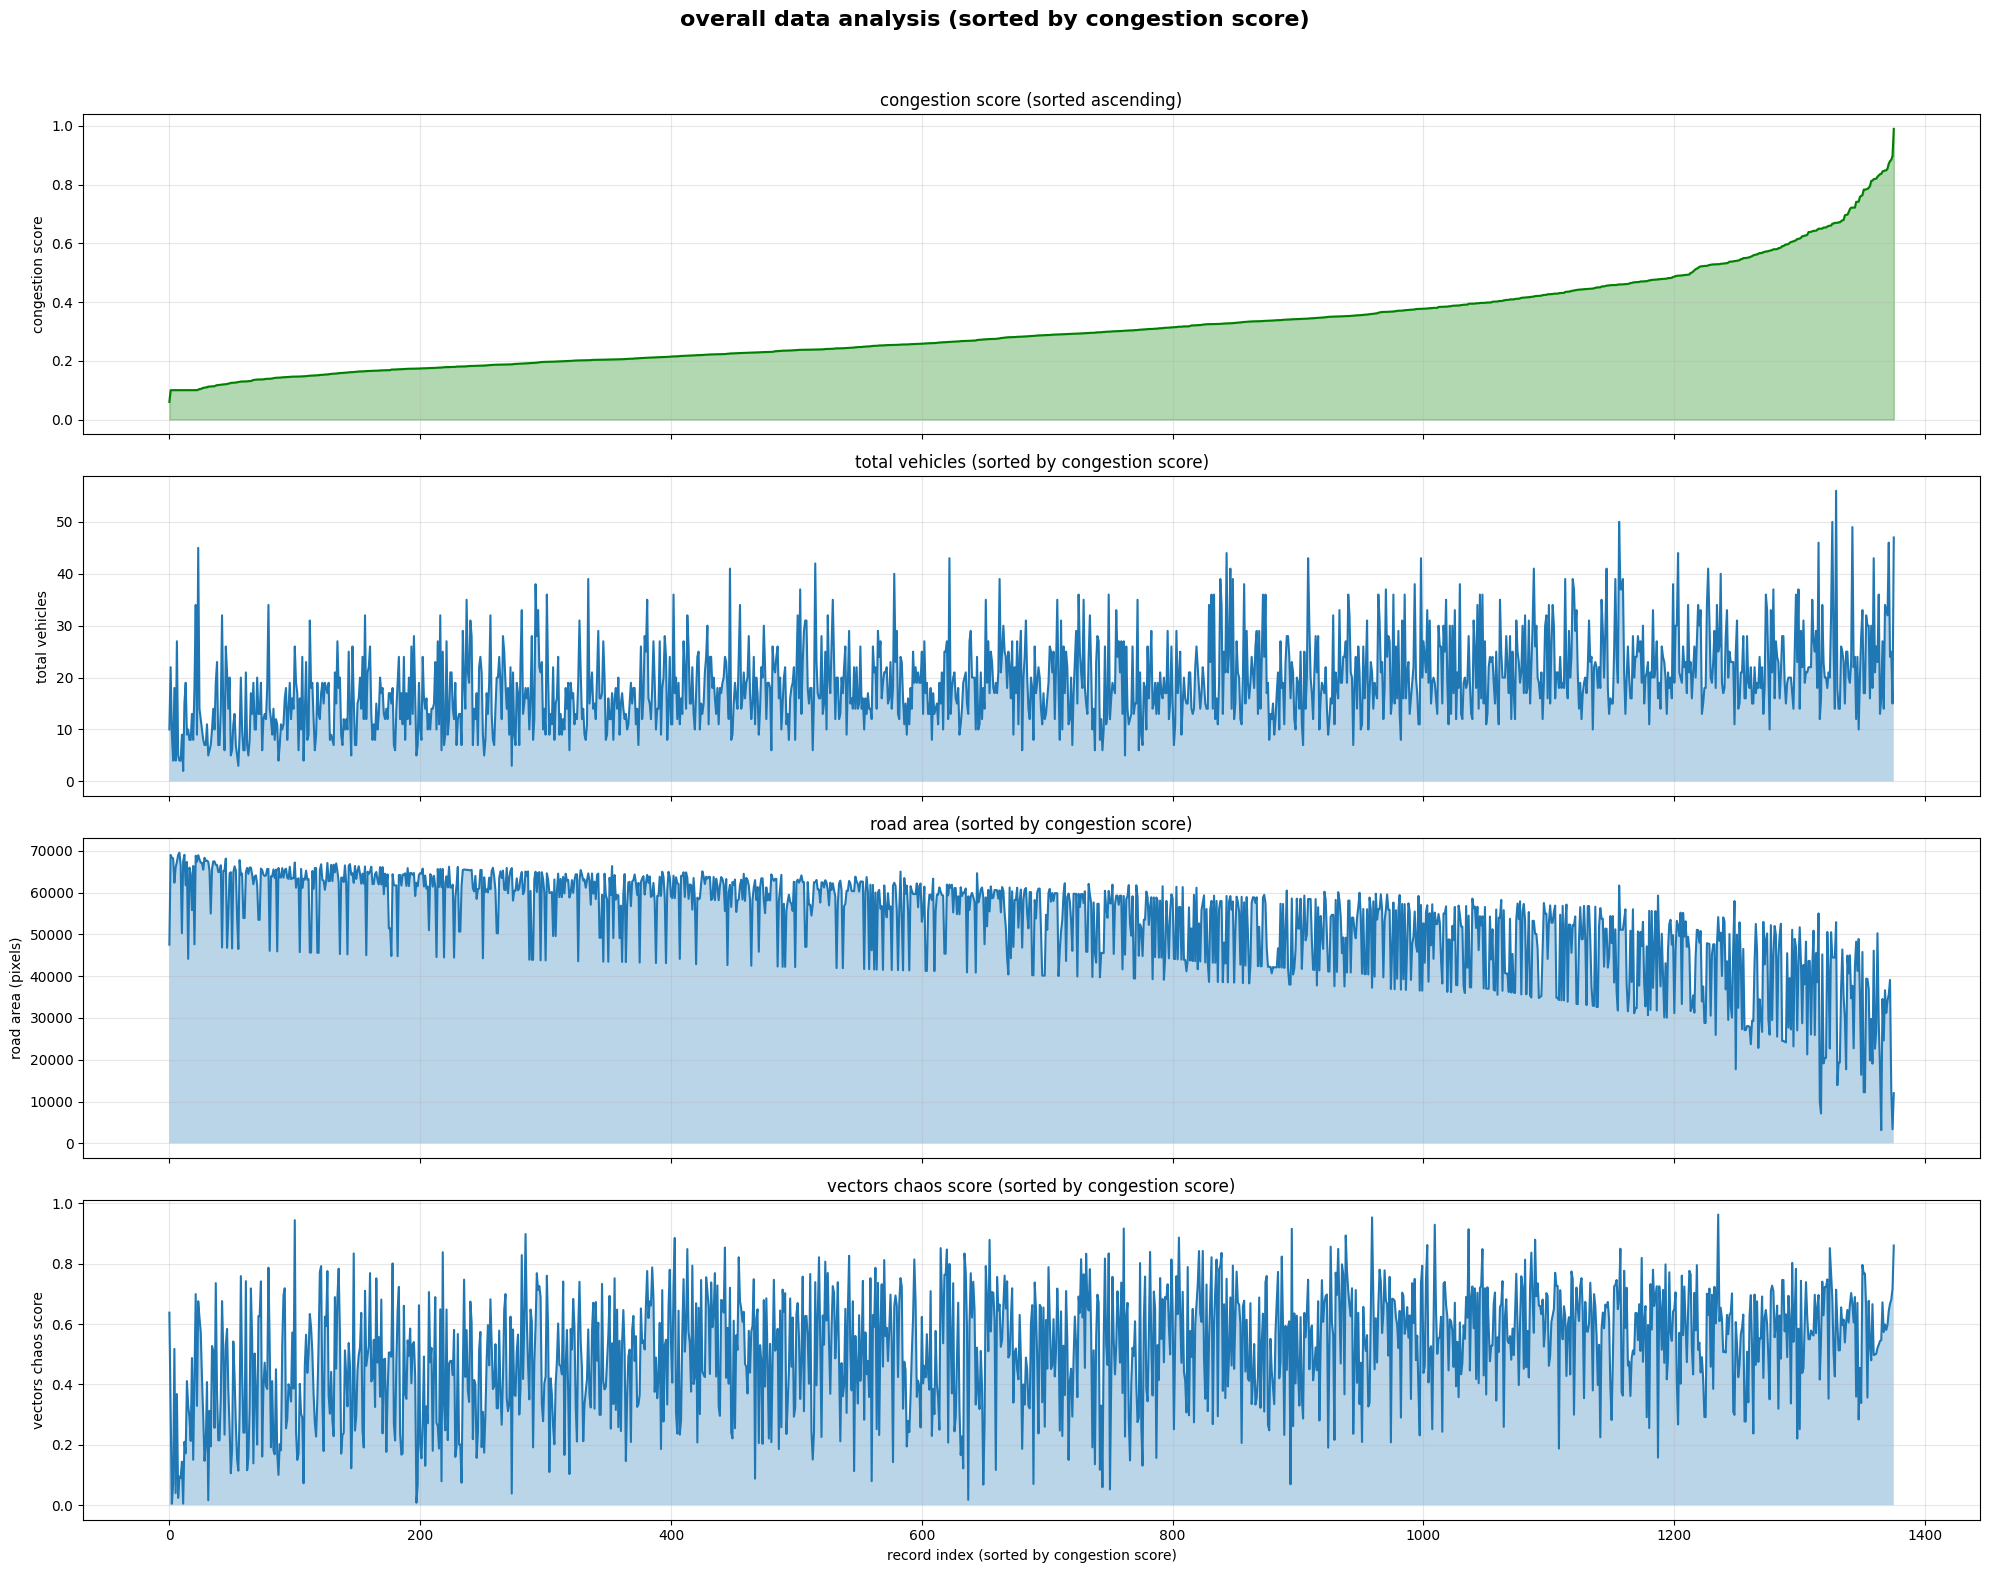


correlation analysis
                    congestion_score  total_vehicles  road_area_pixels  \
congestion_score            1.000000        0.372607         -0.724181   
total_vehicles              0.372607        1.000000         -0.077310   
road_area_pixels           -0.724181       -0.077310          1.000000   
vectors_chao_score          0.286777        0.522656         -0.143973   

                    vectors_chao_score  
congestion_score              0.286777  
total_vehicles                0.522656  
road_area_pixels             -0.143973  
vectors_chao_score            1.000000  


In [11]:
# overall analysis: sorted by congestion_score
# calculate total vehicles
df_analysis = df.copy()
df_analysis['total_vehicles'] = (
    df_analysis['car_count'] +
    df_analysis['truck_count'] +
    df_analysis['bus_count'] +
    df_analysis['motorcycle_count']
)

# sort by congestion_score
df_sorted = df_analysis.sort_values('congestion_score').reset_index(drop=True)
# df_sorted = df_analysis.sort_values('total_vehicles').reset_index(drop=True)

# create index for x-axis
x_index = range(len(df_sorted))

# create 4x1 subplot (1 column, wider display)
fig, axes = plt.subplots(4, 1, figsize=(20, 16), sharex=True)
fig.suptitle(
    'overall data analysis (sorted by congestion score)',
    fontsize=16,
    fontweight='bold'
)

# chart 1: congestion_score
axes[0].plot(x_index, df_sorted['congestion_score'], linewidth=1.5, color='green')
axes[0].set_ylabel('congestion score')
axes[0].set_title('congestion score (sorted ascending)')
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(x_index, df_sorted['congestion_score'], alpha=0.3, color='green')

# chart 2: total vehicles
axes[1].plot(x_index, df_sorted['total_vehicles'], linewidth=1.5)
axes[1].set_ylabel('total vehicles')
axes[1].set_title('total vehicles (sorted by congestion score)')
axes[1].grid(True, alpha=0.3)
axes[1].fill_between(x_index, df_sorted['total_vehicles'], alpha=0.3)

# chart 3: road area
axes[2].plot(x_index, df_sorted['road_area_pixels'], linewidth=1.5)
axes[2].set_ylabel('road area (pixels)')
axes[2].set_title('road area (sorted by congestion score)')
axes[2].grid(True, alpha=0.3)
axes[2].fill_between(x_index, df_sorted['road_area_pixels'], alpha=0.3)

# chart 4: vectors_chao_score
axes[3].plot(x_index, df_sorted['vectors_chao_score'], linewidth=1.5)
axes[3].set_xlabel('record index (sorted by congestion score)')
axes[3].set_ylabel('vectors chaos score')
axes[3].set_title('vectors chaos score (sorted by congestion score)')
axes[3].grid(True, alpha=0.3)
axes[3].fill_between(x_index, df_sorted['vectors_chao_score'], alpha=0.3)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print("\n" + "=" * 60)
print("correlation analysis")
print("=" * 60)
correlation_cols = [
    'congestion_score',
    'total_vehicles',
    'road_area_pixels',
    'vectors_chao_score'
]
print(df_sorted[correlation_cols].corr())


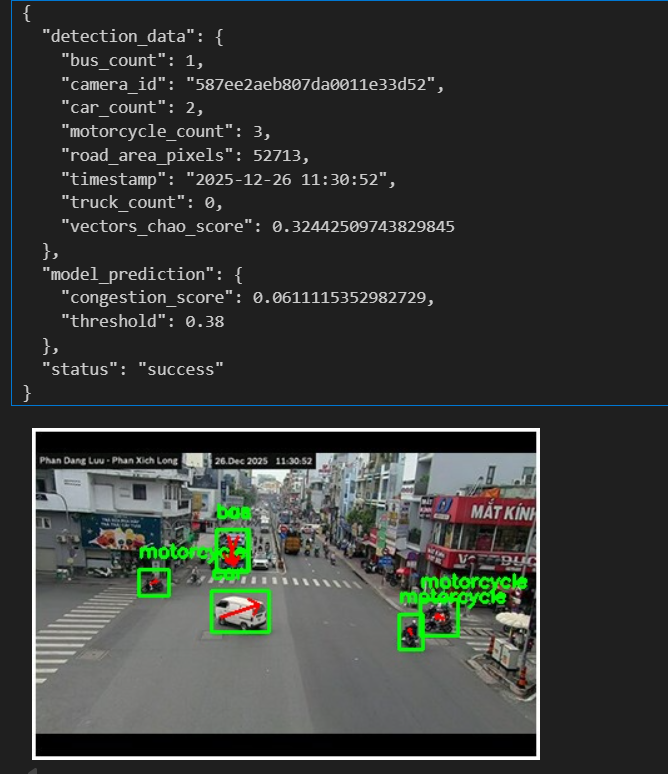 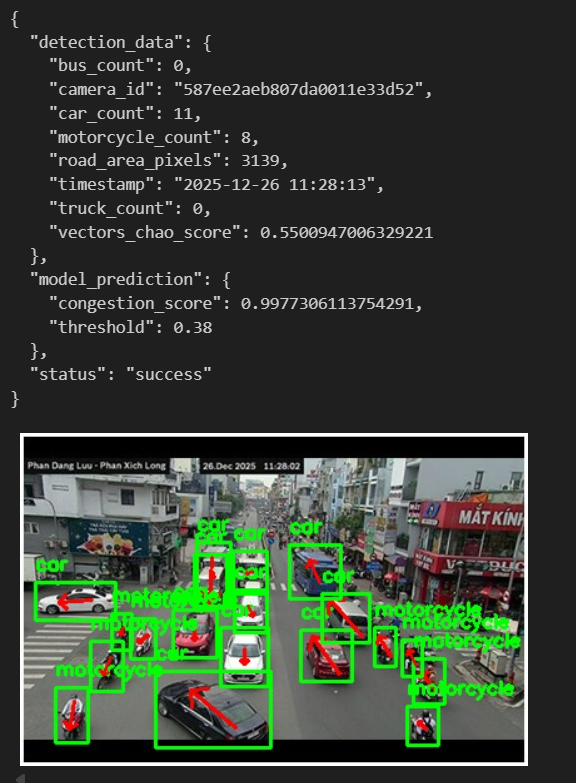

In [18]:
import pandas as pd

# read the input database
df = pd.read_csv('databases.csv')

# format image_name to yyyymmdd_hhmmss.jpg if it is a datetime object
# assuming 'timestamp' is the source column for the name
if 'timestamp' in df.columns:
    df['image_name'] = pd.to_datetime(df['timestamp']).dt.strftime('%Y%m%d_%H%M%S.jpg')

# filter for the required columns
final_df = df[['image_name', 'congestion_score']] 

# export to final_database.csv
final_df.to_csv('final_database.csv', index=False)


<div style="display: flex; justify-content: space-around;">
  <img src="image.png" alt="image_1" width="48%">
  <img src="image_2.png" alt="image_2" width="48%">
</div>